In [ ]:
import pandas as pd #import pandas library to manipulate dataframes
import datetime as dt #import datetime library to deal with date formats
from google.cloud import bigquery
from google.oauth2 import service_account
def read_bigquery_data(query, creds):
    # Create a BigQuery client instance
    credentials = service_account.Credentials.from_service_account_info(creds)
    client = bigquery.Client(credentials=credentials)

    # Execute the query and retrieve the results as a pandas DataFrame
    query_job = client.query(query)
    dataframe = query_job.to_dataframe()

    return dataframe

# Q1. HOW MANY CWS DO WE HAVE? (HISTORICAL AND CURRENT)

Using SQL to load the table.

In [ ]:
query="""
SELECT
*
FROM `restaurant-ops-analytics.case_study.closed_won`
"""

read_bigquery_data(query, creds)

,cw_id,org_id,facility_id,lease_id,cw_date,contract_term,churn_date,termination_date
0,7e199314-bf69-4d80-9da3-096803a55520,c011f990-2241-4ca0-8b7e-18feb0aa5de6,2598cd01-c557-412f-a468-6ca5e65ede5a,902d25c6-65c9-4f38-8a97-b78442a0e984,2023-05-01,1Y3M23D,None,None
1,1c735cbf-cf50-4f92-9ddf-ee79b781e054,e09522bb-d2a4-4593-a0eb-e88d5b925f3b,2598cd01-c557-412f-a468-6ca5e65ede5a,d276bdaf-a704-4e8b-bb09-e1e4539fb486,2023-04-09,2Y7M28D,None,None
2,659fe1de-0e11-45a4-8bad-8c3783c41db7,ca3051a3-4843-4c80-ac3a-fe76fc7194d1,2598cd01-c557-412f-a468-6ca5e65ede5a,d8786e71-0b72-418e-a749-488028349741,2024-04-05,2Y7M30D,None,None
3,fdf0bfef-e3d3-4009-8bcc-b8c3c5ea5251,e9a01819-74f4-4af3-bc9d-7a41e47405ae,2598cd01-c557-412f-a468-6ca5e65ede5a,79ea7376-5b09-4345-895d-94eb1fdd1b02,2024-02-14,1Y1M15D,None,None
4,dd5ac5d7-7ce3-4270-b2bb-ff11aecbe305,6a8effbb-1578-47dd-a500-e2e7c1bf4a57,2598cd01-c557-412f-a468-6ca5e65ede5a,382995d8-715b-4467-81b2-1a0d7445933c,2023-01-11,0Y5M26D,None,None
...,...,...,...,...,...,...,...,...
325,42804c76-affa-496e-ae4f-ed9a941b1379,6020b4f2-4efd-4959-974a-0c08d88b5457,64783e0a-9c83-4e07-8b30-94412639e3ee,4264f428-3e0e-431e-a7c3-78dacb85fd18,2024-07-07,1Y9M21D,2024-07-26,2024-07-26
326,2325dffe-dca7-4dd6-9bac-4a3092be3d41,9c5c83b8-0d65-4917-913e-3581e6eee4ee,849c9c6a-520a-4076-ad97-623769c468ba,b39f8375-02bf-4c12-8940-94ca5b1f9ef5,2023-11-26,0Y11M0D,2024-07-27,2024-07-27
327,e2fffc3e-2732-4389-9f50-a9914f238b38,a49ce980-b7f0-4f31-bd4c-9ebaf51a727e,664c7ed2-3f04-4e7f-a5da-cf7cfb7f2123,98721d86-87ae-4d92-923d-a17efea17683,2024-06-28,2Y4M3D,2024-07-29,2024-07-29
328,7d97a93a-c80a-4941-a165-f9a08756cc53,e9a01819-74f4-4af3-bc9d-7a41e47405ae,ff3d02c5-5628-4faf-875c-ec0f83d84a7a,f80e6534-02ea-4a32-8f70-83d37494c50a,2023-12-24,0Y12M10D,2024-07-29,2024-07-29


WORKING WITH PYTHON FOR THE FIRST QUESTION:

> Firs of all I created a Df to load the whole CW table.



In [ ]:
df_cw = read_bigquery_data(query, creds)

Converting the Columns for Date Type

> Using the Pyhton library DATETIME and print the results to check if the values were converted to date type.



In [ ]:
df_cw['cw_date'] = pd.to_datetime(df_cw['cw_date'])
df_cw['cw_date']

,cw_date
0,2023-05-01
1,2023-04-09
2,2024-04-05
3,2024-02-14
4,2023-01-11
...,...
325,2024-07-07
326,2023-11-26
327,2024-06-28
328,2023-12-24


In [ ]:
df_cw['termination_date'] = pd.to_datetime(df_cw['termination_date'])
df_cw['termination_date']

,termination_date
0,NaT
1,NaT
2,NaT
3,NaT
4,NaT
...,...
325,2024-07-26
326,2024-07-27
327,2024-07-29
328,2024-07-29


Historical amount of CWs

> Using the function 'groupby' I could create a column for each month and another column bringing how many contracts we get historical since the first date of the table.



In [ ]:
cw_per_month = (
    df_cw
    .groupby(df_cw['cw_date'].dt.to_period('M'))['cw_id']
    .nunique() # --- This is very important, using '.nunique' the script are using count.DISTINCT avoiding double counts or mistakes
    .reset_index()
)

print(cw_per_month)

    cw_date  cw_id
0   2023-01     16
1   2023-02     13
2   2023-03     16
3   2023-04     21
4   2023-05     16
5   2023-06     18
6   2023-07     16
7   2023-08     13
8   2023-09     21
9   2023-10      9
10  2023-11     24
11  2023-12     19
12  2024-01     15
13  2024-02     14
14  2024-03     20
15  2024-04     28
16  2024-05     20
17  2024-06     15
18  2024-07     16


Current CWs



In [ ]:
cutoff = pd.Timestamp("2024-08-01") #--- cutoff date provided in the case study

Created a month range to track all contracts availables before the cutoff date.

In [ ]:
month_range = pd.date_range(start=df_cw["cw_date"].min(),
                            end=cutoff, freq="MS")



*   For the same exercise, I created multiple columns. How many churned CWs per month;
*   The total current CWs until the last day of the month. Acumulating month by month to reach the total of current CWs;


*   Considering the = (Total of Historical CW - Churned CWs) the last column 'active_change' is the number of current CWs that is not finised.





In [ ]:
results = []

for month_start in month_range:
    month_end = month_start + pd.offsets.MonthEnd(0)

    started = df_cw[
        (df_cw["cw_date"] >= month_start) &
        (df_cw["cw_date"] <= month_end)
    ]["cw_id"].nunique()

    churned = df_cw[
        (df_cw["termination_date"].notna()) &
        (df_cw["termination_date"] >= month_start) &
        (df_cw["termination_date"] <= month_end)
    ]["cw_id"].nunique()

    active = df_cw[
        (df_cw["cw_date"] <= month_end) &
        (df_cw["termination_date"].isna() | (df_cw["termination_date"] > month_end))
    ]["cw_id"].nunique()

    results.append({
        "month": month_start,
        "new_cw": started,
        "churn_cw": churned,
        "active_cw_end_month": active
    })

df_monthly = pd.DataFrame(results)
df_monthly["active_change"] = df_monthly["active_cw_end_month"].diff()

print(df_monthly)

        month  new_cw  churn_cw  active_cw_end_month  active_change
0  2023-02-01      13         0                   29            NaN
1  2023-03-01      16         2                   43           14.0
2  2023-04-01      21         3                   61           18.0
3  2023-05-01      16         2                   75           14.0
4  2023-06-01      18         1                   92           17.0
5  2023-07-01      16         1                  107           15.0
6  2023-08-01      13         3                  117           10.0
7  2023-09-01      21         2                  136           19.0
8  2023-10-01       9         3                  142            6.0
9  2023-11-01      24         3                  163           21.0
10 2023-12-01      19         4                  178           15.0
11 2024-01-01      15         3                  190           12.0
12 2024-02-01      14        11                  193            3.0
13 2024-03-01      20         7                 

# Q2. WICH ARE THE MOST SUCCESSFUL RESTAURANTS ACROSS THE COUNTRY? (CURRENT AND HISTORICAL)

- Assuming that Restaurants Dimension is the Organization ID because the Organization represents the brand, the owner of the restaurant
- First I joined Orders with the Restaurant Dimension and aggregated the Restaurants + Region and calculate the GMV Historical;
- Based on the current months calculated the Monthly GMV;
- At last I create 2 independent rankings for Region:
1.   Based on GMV Historical
2.   Based on Monthly GMV

In [ ]:
query="""
DECLARE current_months INT64 DEFAULT 3;
DECLARE top_n INT64 DEFAULT 5;

WITH base AS (
  SELECT
    o.org_id,
    d.org_name,
    fac.region,
    DATE_TRUNC(DATE(o.order_timestamp), MONTH) AS month_start,
    SAFE_CAST(o.subtotal AS FLOAT64) AS gmv
  FROM `restaurant-ops-analytics.case_study.orders` o
  JOIN `restaurant-ops-analytics.case_study.organization` d
    ON o.org_id = d.org_id
  JOIN `restaurant-ops-analytics.case_study.closed_won` cw
    ON o.org_id = cw.org_id
  JOIN `restaurant-ops-analytics.case_study.facility` fac
    ON cw.facility_id = fac.facility_id
  WHERE o.order_timestamp IS NOT NULL
),

agg AS (
  SELECT
    org_id,
    org_name,
    region,

    -- Calculating Historical GMV
    SUM(gmv) AS gmv_historical,

    -- Current GMV
    SUM(
      CASE
        WHEN month_start >= DATE_SUB(
          (SELECT MAX(month_start) FROM base),
          INTERVAL (current_months - 1) MONTH
        )
        THEN gmv
        ELSE 0
      END
    ) AS gmv_current

  FROM base
  GROUP BY org_id, org_name, region
),

ranked AS (
  SELECT
    *,
    ROW_NUMBER() OVER (
      PARTITION BY region
      ORDER BY gmv_current DESC
    ) AS rank_current,

    ROW_NUMBER() OVER (
      PARTITION BY region
      ORDER BY gmv_historical DESC
    ) AS rank_historical
  FROM agg
)

SELECT
  org_id,
  org_name,
  region,
  gmv_current,
  gmv_historical,
  rank_current,
  rank_historical
FROM ranked
WHERE rank_current <= top_n
   OR rank_historical <= top_n
ORDER BY region, rank_current, rank_historical;
"""

read_bigquery_data(query, creds)

,org_id,org_name,region,gmv_current,gmv_historical,rank_current,rank_historical
0,893aa5b0-cc14-442e-9aea-f2fefb67ee22,Organization 152,East,1352860.44,4184048.72,1,2
1,e9a01819-74f4-4af3-bc9d-7a41e47405ae,Organization 125,East,1344704.56,5127433.24,2,1
2,cb764f95-eecc-4154-92d7-887346c615ef,Organization 119,East,834160.17,934401.45,3,13
3,a91f73f3-300a-4c4d-9c54-af9bee53e118,Organization 51,East,800197.82,1331710.52,4,6
4,8e4e50da-34e4-482c-baea-17fd8f077107,Organization 90,East,759537.64,781068.12,5,16
5,d7d3d43e-ac6e-4b84-b6d3-d8d86b916129,Organization 41,East,410875.71,2815854.63,9,3
6,cfb07b3e-5c0d-4d92-b123-73cb1afdb1bc,Organization 190,East,101970.42,1779356.94,39,5
7,fce1530b-ff28-43f5-8358-0b8daff48a5f,Organization 174,East,91729.71,2418930.66,42,4
8,e5f0e874-761b-4517-a4cc-9c65da500107,Organization 206,North,1602813.69,4466586.81,1,1
9,64735828-2a2c-4773-901a-2c343e4b9561,Organization 25,North,777941.62,1086084.98,2,5


In [ ]:
from google.colab import files
df_region.to_excel('df_region.xlsx', index=False)
files.download('df_region.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Q3. WICH RESTAURANTS ARE ELIGIBLE FOR EXPANSION? (CURRENT)


- For this particular question I need to consider for expansion: if a restaurant's monthly GMV exceeds 45k for a given month and it has been more than 100 days since their organization's last CW.

In [ ]:
query="""
--- Selecting the Org_ID and calculating the GMV per month to find the organizations eligible for expansion.
WITH gmv_org_month AS (
  SELECT
    cw.org_id,
    FORMAT_TIMESTAMP('%Y-%m', PARSE_TIMESTAMP('%Y-%m-%d', ord.order_timestamp)) AS month,
    SUM(ord.subtotal) AS monthly_gmv
  FROM `restaurant-ops-analytics.case_study.orders` ord
  JOIN `restaurant-ops-analytics.case_study.closed_won` cw
    ON ord.org_id = cw.org_id
  GROUP BY cw.org_id, month
),

--- In this block I filtered the last date of the contract for each organization to check how many days passed since the last contract.
last_cw AS (
  SELECT
    org_id,
    MAX(cw_date) AS last_cw_date
    FROM `restaurant-ops-analytics.case_study.closed_won`
    GROUP BY org_id
),

--- Distinct count to avoid duplicated values;
org_facilities AS (
  SELECT DISTINCT
    cw.org_id,
    cw.facility_id
  FROM `restaurant-ops-analytics.case_study.closed_won` cw
  )

  SELECT
    o.org_id,
    o.org_name,
    f.facility_id,
    fac.name AS facility_name,

    g.month AS reference_month,
    g.monthly_gmv,

    l.last_cw_date,
    DATE_DIFF(DATE '2024-08-31', PARSE_DATE('%Y-%m-%d', l.last_cw_date), DAY) AS days_since_last_cw,

    DATE '2024-09-01' AS expansion_month,

--- Join tables with Primary Key to create a relationship between the tables.
  FROM gmv_org_month g
  JOIN last_cw l
    ON g.org_id = l.org_id
  JOIN org_facilities f
    ON g.org_id = f.org_id
  JOIN `restaurant-ops-analytics.case_study.organization` o
    ON g.org_id = o.org_id
  JOIN `restaurant-ops-analytics.case_study.facility` fac
    ON f.facility_id = fac.facility_id

--- Set the GMV > 45k and the days since last CW > 100 days.
  WHERE g.month = '2024-08'
    AND g.monthly_gmv > 45000
    AND DATE_DIFF(DATE '2024-08-31', PARSE_DATE('%Y-%m-%d', l.last_cw_date), DAY) > 100.
--- Order the results by GMV from the Highest GMV to the Lowest and by the days > 100 days.
  ORDER BY g.monthly_gmv DESC;
"""
df_expansion = read_bigquery_data(query,creds)

In [ ]:
df_expansion['org_id'].nunique()

19

In [ ]:
from google.colab import files
df_expansion.to_excel('df_expansion.xlsx', index=False)
files.download('df_expansion.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

- Basically only 25 Restaurants are eligible to expand according to the rules in the Study Case.

# Q4. WHAT IS THE GMV PER FACILITY? (CURRENT AND HISTORICAL)



*   For this question, used SQL language again.
*   First, I transform the Data type into 'YYYY-MM' it is easier to mantain a pattern.


*   Joined the tables ORDERS + CLOSED WON + FACILITY because the CLOSED WON table has the Primary Key to create a relationship with the other both tables.
*   Then I grouped Month, Facility ID and Name to avoid duplicated values of the GMV.





In [ ]:
query="""
SELECT
  FORMAT_TIMESTAMP('%Y-%m', PARSE_TIMESTAMP('%Y-%m-%d', ord.order_timestamp)) AS month,
  cw.facility_id,
  fac.name AS facility_name,
  SUM(ord.subtotal) AS monthly_gmv
FROM `restaurant-ops-analytics.case_study.orders` ord
JOIN `restaurant-ops-analytics.case_study.closed_won` cw
  ON ord.org_id = cw.org_id
JOIN `restaurant-ops-analytics.case_study.facility` fac
  ON cw.facility_id = fac.facility_id
GROUP BY month, cw.facility_id, fac.name
ORDER BY month, monthly_gmv DESC;
"""
read_bigquery_data(query,creds)

,month,facility_id,facility_name,monthly_gmv
0,2023-01,849c9c6a-520a-4076-ad97-623769c468ba,Facility 4,90788.54
1,2023-01,ff3d02c5-5628-4faf-875c-ec0f83d84a7a,Facility 2,55577.74
2,2023-01,2598cd01-c557-412f-a468-6ca5e65ede5a,Facility 1,48197.56
3,2023-01,664c7ed2-3f04-4e7f-a5da-cf7cfb7f2123,Facility 5,38708.86
4,2023-01,64783e0a-9c83-4e07-8b30-94412639e3ee,Facility 10,32222.15
...,...,...,...,...
194,2024-08,2ec5107d-09b5-4352-8e7a-db658ec63e4f,Facility 8,511790.63
195,2024-08,465052c9-8ff5-41d5-81db-35c0991d8f40,Facility 7,470474.99
196,2024-08,849c9c6a-520a-4076-ad97-623769c468ba,Facility 4,351573.06
197,2024-08,2598cd01-c557-412f-a468-6ca5e65ede5a,Facility 1,276677.95




*   Considering the current period (cutoff = 2024-08)

*   I set the Order Date >= 2024-08
*   Grouped the Facility ID and Name to avoid dplicated values

*   And order the GMV Value from the MAX Value to MIN.



In [ ]:
query_aug="""
SELECT
  cw.facility_id,
  fac.name AS facility_name,
  SUM(ord.subtotal) AS gmv_aug_2024
FROM `restaurant-ops-analytics.case_study.orders` ord
JOIN `restaurant-ops-analytics.case_study.closed_won` cw
  ON ord.org_id = cw.org_id
JOIN `restaurant-ops-analytics.case_study.facility` fac
  ON cw.facility_id = fac.facility_id
WHERE PARSE_DATE('%Y-%m-%d', ord.order_timestamp) >= '2024-08-01'
GROUP BY cw.facility_id, facility_name
ORDER BY gmv_aug_2024 DESC;
"""
read_bigquery_data(query,creds)

,month,facility_id,facility_name,monthly_gmv
0,2023-01,849c9c6a-520a-4076-ad97-623769c468ba,Facility 4,90788.54
1,2023-01,ff3d02c5-5628-4faf-875c-ec0f83d84a7a,Facility 2,55577.74
2,2023-01,2598cd01-c557-412f-a468-6ca5e65ede5a,Facility 1,48197.56
3,2023-01,664c7ed2-3f04-4e7f-a5da-cf7cfb7f2123,Facility 5,38708.86
4,2023-01,64783e0a-9c83-4e07-8b30-94412639e3ee,Facility 10,32222.15
...,...,...,...,...
194,2024-08,2ec5107d-09b5-4352-8e7a-db658ec63e4f,Facility 8,511790.63
195,2024-08,465052c9-8ff5-41d5-81db-35c0991d8f40,Facility 7,470474.99
196,2024-08,849c9c6a-520a-4076-ad97-623769c468ba,Facility 4,351573.06
197,2024-08,2598cd01-c557-412f-a468-6ca5e65ede5a,Facility 1,276677.95


The same exercise above I created in Python.


*   The main idea is to create a plot with the library matplotlib and identify the results;
*   Put the table inside a pandas DF and set the visual for the Ten current facilities with the highest GMV;





In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [ ]:
df_facility_aug = read_bigquery_data(query_aug, creds)

In [ ]:
TOP_N = 10 #The first ten current facilities with highest GMV

In [ ]:
df_plot = (
    df_facility_aug
    .sort_values(by='gmv_aug_2024', ascending=False)
    .head(TOP_N)
)



*   In this block I inserted the values for the axis, title, labels in the horizontal bars;
*   And now we can see the 10 facilities with highest GMV;



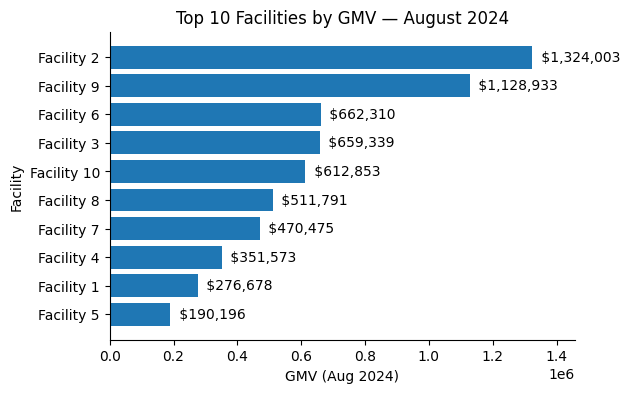

In [ ]:
plt.figure(figsize=(6, 4), dpi=100) #define the size of the chart, removed constrained_layout=True

bars = plt.barh(
    df_plot["facility_name"][::-1],
    df_plot["gmv_aug_2024"][::-1]
    )

plt.xlabel("GMV (Aug 2024)") #X axis provides the GMV values
plt.ylabel("Facility") #Y axis provides the TOP 10 facilities
plt.title(f"Top {TOP_N} Facilities by GMV — August 2024") #Creating title for the chart


ax = plt.gca() # Correctly get the current axes

ax.spines['top'].set_visible(False) # Remove the top border
ax.spines['right'].set_visible(False) # Remove the right border

# --- Extend x-axis limit to make space for labels ---
max_gmv = df_plot["gmv_aug_2024"].max()
ax.set_xlim(right=max_gmv * 1.1) # Extend by 10% more space on the right


# --- Insert labels in the Bars ---
for bar in bars:
  width = bar.get_width()
  plt.text(
      width + (max_gmv * 0.01), # Place slightly to the right of the bar's end
      bar.get_y() + bar.get_height() / 2,
      f' ${width:,.0f}',
      va='center',
      ha='left',
      fontsize=10
  )

plt.show()

# Q5. What is the % of Sold Kitchens?



*   Combined the tables Closed Won + Facilty. To identify how many CW each facility has and how many kitchens inside the facility;
*   To calculate the percentage of sold kitchens I took the number of CW divided by number of kitchens to reach the results;



In [ ]:
q_cw = """
SELECT
  cw_id,
  facility_id,
  DATE(cw_date) AS cw_date,
  DATE(termination_date) AS termination_date
FROM `restaurant-ops-analytics.case_study.closed_won`
"""
# --- Reading the CWs table above and inserting in a DF
df_cw = read_bigquery_data(q_cw, creds)

q_fac = """
SELECT
  facility_id,
  name,
  number_of_kitchens
FROM `restaurant-ops-analytics.case_study.facility`
"""
# --- Reading the Facility table above and inserting in a DF
df_fac = read_bigquery_data(q_fac, creds)

# --- Transforming the columns into DATES
df_cw["cw_date"] = pd.to_datetime(df_cw["cw_date"])
df_cw["termination_date"] = pd.to_datetime(df_cw["termination_date"])

# --- List of Months
start_month = df_cw["cw_date"].min().to_period("M").to_timestamp() # --- Adjusting the dates considering "to_period(M)" means that I am looking for whole month
end_month = pd.Timestamp("2024-08-01") # --- Using the Timestamp clause we consider the begining of the month
months = pd.date_range(start=start_month, end=end_month, freq="MS")

def active_kitchens_per_fac(month_start: pd.Timestamp) -> pd.DataFrame:
  month_end = month_start + pd.offsets.MonthEnd(0) # --- Adjusting the dates considering the last day for the var "month_end"

  active_kitchens = df_cw[
      (df_cw["cw_date"] <= month_end) &
      (df_cw["termination_date"].isna() | (df_cw["termination_date"] > month_end))
  ]

  out = (active_kitchens.groupby("facility_id")["cw_id"].nunique().reset_index())
  out["month"] = month_start
  return out

df_active = pd.concat([active_kitchens_per_fac(m) for m in months], ignore_index=True)

df_sold = df_active.merge(df_fac, on="facility_id", how="left")
df_sold["sold_kitchens_pct"] = (
    df_sold["cw_id"] / df_sold["number_of_kitchens"]
)

df_sold

,facility_id,cw_id,month,name,number_of_kitchens,sold_kitchens_pct
0,2598cd01-c557-412f-a468-6ca5e65ede5a,3,2023-01-01,Facility 1,22,0.136364
1,849c9c6a-520a-4076-ad97-623769c468ba,3,2023-01-01,Facility 4,28,0.107143
2,9960afa1-47d7-43cc-8fab-dec9dccfa23d,2,2023-01-01,Facility 6,30,0.066667
3,e2a4aeda-4cbf-4194-b71c-58267a2c398c,1,2023-01-01,Facility 3,18,0.055556
4,ff3d02c5-5628-4faf-875c-ec0f83d84a7a,7,2023-01-01,Facility 2,27,0.259259
...,...,...,...,...,...,...
190,849c9c6a-520a-4076-ad97-623769c468ba,23,2024-08-01,Facility 4,28,0.821429
191,8e8adce6-953a-4d21-b175-131517b34b59,25,2024-08-01,Facility 9,20,1.25
192,9960afa1-47d7-43cc-8fab-dec9dccfa23d,29,2024-08-01,Facility 6,30,0.966667
193,e2a4aeda-4cbf-4194-b71c-58267a2c398c,22,2024-08-01,Facility 3,18,1.222222


In [ ]:
from google.colab import files
df_sold.to_excel('df_sold.xlsx', index=False)
files.download('df_sold.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

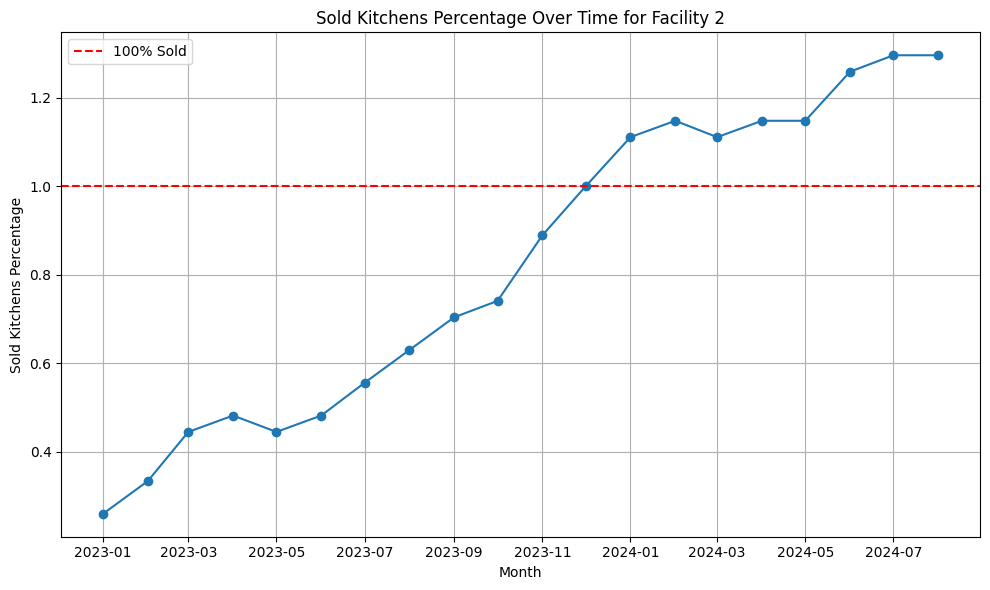

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter for 'Facility 2'
df_facility2 = df_sold[df_sold['name'] == 'Facility 2'].copy()

# Ensure 'month' is in datetime format for proper plotting
df_facility2['month'] = pd.to_datetime(df_facility2['month'])

# Sort by month to ensure correct time series plotting
df_facility2 = df_facility2.sort_values(by='month')

plt.figure(figsize=(10, 6))
plt.plot(df_facility2['month'], df_facility2['sold_kitchens_pct'], marker='o', linestyle='-')
plt.xlabel('Month')
plt.ylabel('Sold Kitchens Percentage')
plt.title('Sold Kitchens Percentage Over Time for Facility 2')
plt.grid(True)
plt.axhline(1, color='red', linestyle='--', label='100% Sold') # Add a reference line for 100%
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
facility2_id = df_fac[df_fac['name'] == 'Facility 2']['facility_id'].iloc[0]
df_cw_facility2 = df_cw[df_cw['facility_id'] == facility2_id]
display(df_cw_facility2.sort_values(by='cw_date', ascending=True))

,cw_id,facility_id,cw_date,termination_date
229,f42df4b7-5ae5-4814-856e-306254a148c5,ff3d02c5-5628-4faf-875c-ec0f83d84a7a,2023-01-03,NaT
225,27ecd917-2bc6-4fd8-b04c-72a66d933a1a,ff3d02c5-5628-4faf-875c-ec0f83d84a7a,2023-01-04,NaT
217,5b16b895-b920-4a3a-abe6-b4403a7a8d56,ff3d02c5-5628-4faf-875c-ec0f83d84a7a,2023-01-05,NaT
214,ad70d06e-fb94-40f0-82fc-956fa4c3a673,ff3d02c5-5628-4faf-875c-ec0f83d84a7a,2023-01-22,NaT
240,913d5f83-4b32-4168-bd16-d7c443bb1707,ff3d02c5-5628-4faf-875c-ec0f83d84a7a,2023-01-22,NaT
306,40daf222-fa0c-4850-b7ed-29a92d1fc5ed,ff3d02c5-5628-4faf-875c-ec0f83d84a7a,2023-01-25,2024-05-24
230,112df69c-8539-42b9-9a0e-004072df3848,ff3d02c5-5628-4faf-875c-ec0f83d84a7a,2023-01-28,NaT
243,d8614bd9-9e76-4e00-b083-b574017d7cbf,ff3d02c5-5628-4faf-875c-ec0f83d84a7a,2023-02-05,NaT
254,718548b9-2dc7-45f7-ae7b-8b197b3bf2f9,ff3d02c5-5628-4faf-875c-ec0f83d84a7a,2023-02-25,2023-05-30
238,7b132508-8214-4cef-8809-c9c78ce566d3,ff3d02c5-5628-4faf-875c-ec0f83d84a7a,2023-03-13,NaT


In [ ]:
df_sold_greater_than_1 = df_sold[df_sold['sold_kitchens_pct'] > 1]
display(df_sold_greater_than_1.sort_values(by='sold_kitchens_pct', ascending=False))

,facility_id,cw_id,month,name,number_of_kitchens,sold_kitchens_pct
194,ff3d02c5-5628-4faf-875c-ec0f83d84a7a,35,2024-08-01,Facility 2,27,1.296296
184,ff3d02c5-5628-4faf-875c-ec0f83d84a7a,35,2024-07-01,Facility 2,27,1.296296
183,e2a4aeda-4cbf-4194-b71c-58267a2c398c,23,2024-07-01,Facility 3,18,1.277778
174,ff3d02c5-5628-4faf-875c-ec0f83d84a7a,34,2024-06-01,Facility 2,27,1.259259
181,8e8adce6-953a-4d21-b175-131517b34b59,25,2024-07-01,Facility 9,20,1.25
191,8e8adce6-953a-4d21-b175-131517b34b59,25,2024-08-01,Facility 9,20,1.25
193,e2a4aeda-4cbf-4194-b71c-58267a2c398c,22,2024-08-01,Facility 3,18,1.222222
155,2598cd01-c557-412f-a468-6ca5e65ede5a,26,2024-05-01,Facility 1,22,1.181818
171,8e8adce6-953a-4d21-b175-131517b34b59,23,2024-06-01,Facility 9,20,1.15
161,8e8adce6-953a-4d21-b175-131517b34b59,23,2024-05-01,Facility 9,20,1.15


In [ ]:
average_sold_kitchens_per_facility = df_sold.groupby(['facility_id', 'name'])['sold_kitchens_pct'].mean().reset_index()
display(average_sold_kitchens_per_facility.sort_values(by='sold_kitchens_pct', ascending=False))

,facility_id,name,sold_kitchens_pct
9,ff3d02c5-5628-4faf-875c-ec0f83d84a7a,Facility 2,0.824074
6,8e8adce6-953a-4d21-b175-131517b34b59,Facility 9,0.821053
0,2598cd01-c557-412f-a468-6ca5e65ede5a,Facility 1,0.736364
8,e2a4aeda-4cbf-4194-b71c-58267a2c398c,Facility 3,0.736111
2,465052c9-8ff5-41d5-81db-35c0991d8f40,Facility 7,0.635789
7,9960afa1-47d7-43cc-8fab-dec9dccfa23d,Facility 6,0.598333
1,2ec5107d-09b5-4352-8e7a-db658ec63e4f,Facility 8,0.532632
5,849c9c6a-520a-4076-ad97-623769c468ba,Facility 4,0.505357
3,64783e0a-9c83-4e07-8b30-94412639e3ee,Facility 10,0.432749
4,664c7ed2-3f04-4e7f-a5da-cf7cfb7f2123,Facility 5,0.402105




*   But something claimed my atention there is some facilities that sold more than 100% of the kitchens.
*   To understand the situation I filtered the column 'sold_kitchens' > 1 and listed the ten highest values;



In [ ]:
df_sold[df_sold["sold_kitchens_pct"] > 1] \
    [["month","name","cw_id","number_of_kitchens","sold_kitchens_pct"]] \
    .sort_values("sold_kitchens_pct", ascending=False) \
    .head(10)

,month,name,cw_id,number_of_kitchens,sold_kitchens_pct
194,2024-08-01,Facility 2,35,27,1.296296
184,2024-07-01,Facility 2,35,27,1.296296
183,2024-07-01,Facility 3,23,18,1.277778
174,2024-06-01,Facility 2,34,27,1.259259
181,2024-07-01,Facility 9,25,20,1.25
191,2024-08-01,Facility 9,25,20,1.25
193,2024-08-01,Facility 3,22,18,1.222222
155,2024-05-01,Facility 1,26,22,1.181818
171,2024-06-01,Facility 9,23,20,1.15
161,2024-05-01,Facility 9,23,20,1.15




*   And plot the values to get a better view;


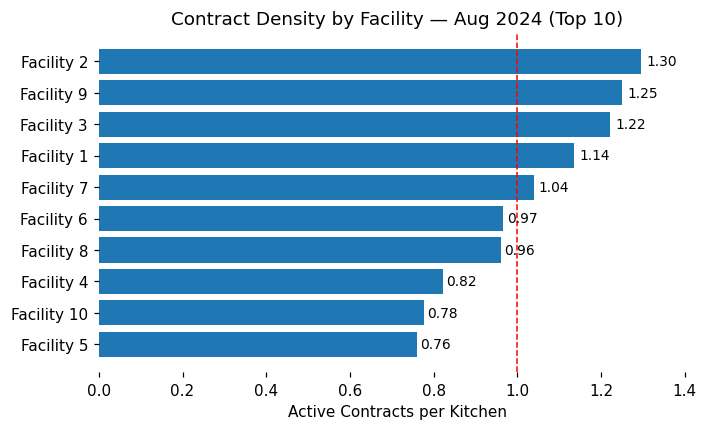

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4), dpi=110) # Removed constrained_layout=True

# Select top N facilities from df_sold_aug for plotting contract density
df_plot_density = df_sold_aug.head(TOP_N)

bars = plt.barh(
    df_plot_density["name"][::-1],  # Use 'name' column for facility names
    df_plot_density["sold_kitchens_pct"][::-1] # Use 'sold_kitchens_pct' for density
)

plt.xlabel("Active Contracts per Kitchen")
plt.title(f"Contract Density by Facility — Aug 2024 (Top {TOP_N})") # Adjusted title

# Linha de referência = 1 contrato por cozinha
plt.axvline(1, linestyle="--", linewidth=1, color='red') # Added color for visibility

# Labels nas barras
for bar in bars:
    value = bar.get_width()
    plt.text(
        value * 1.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        fontsize=9
    )

# Remover bordas
ax = plt.gca()
for spine in ["top","right","left","bottom"]:
    ax.spines[spine].set_visible(False)

# Adjust x-axis limits for better visualization
max_density = df_plot_density["sold_kitchens_pct"].max()
ax.set_xlim(right=max_density * 1.1) # Extend by 10% more space on the right

plt.show()

My conclusions analyzing the data and the problem:
- The same Kitchen can have more than 1 active CW;
- An old CW that stil active in the sistem and a new CW is already active overlaping the CW date;
- And there is not a column 'kitchen_id' in the dataset without the relationship 1:1 I can not validate if there is more than 1 CW for the same kitchen;